In [6]:
import emlearn
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [9]:
path = kagglehub.dataset_download("uciml/electric-power-consumption-data-set")

print("Path to dataset files:", path)

df = pd.read_csv(path + '/household_power_consumption.txt',
                 sep=';',
                 low_memory=False,
                 na_values=['nan', '?'],
                 converters={'Date': str, 'Time': str})

df.index = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
df = df.drop(['Date', 'Time'], axis=1)

Path to dataset files: C:\Users\brill\.cache\kagglehub\datasets\uciml\electric-power-consumption-data-set\versions\1


In [10]:
data_head = df.head()
data_head

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [11]:
data_clear = df.dropna()

In [21]:
# 1) Load & resample
data_clear = data_clear[["Global_active_power", "Global_reactive_power"]]
data_resample = data_clear.resample('30Min').mean().dropna().reset_index(drop=True)

# 2) Create lag features
n_lags = 5
lagged = [data_resample.shift(lag).add_suffix(f"_lag{lag}") for lag in range(1, n_lags + 1)]
X_lagged = pd.concat(lagged, axis=1).iloc[n_lags:].reset_index(drop=True)
y_lagged = data_resample["Global_active_power"].iloc[n_lags:].reset_index(drop=True)

# 3) Split
X_train, X_test, y_train, y_test = train_test_split(
    X_lagged, y_lagged, test_size=0.3, shuffle=False, random_state=42
)

# 4) Quantize X to int16 in [-32768, +32767]
scaler_X = MinMaxScaler(feature_range=(-1, 1))
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

X_train_int16 = (X_train_scaled * 32767).astype('int16')
X_test_int16 = (X_test_scaled * 32767).astype('int16')

# 6) Train on integer data
model = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)
model.fit(X_train_int16, y_train)

# 7) Evaluate in Python
py_pred = model.predict(X_test_int16)

# compute RMSE:
y_true = y_test.values
rmse = np.sqrt(mean_squared_error(y_true, py_pred))
print(f"Test RMSE: {rmse:.3f}")

# 8) Export quantized C model
cmodel = emlearn.convert(model, method='inline', dtype='int16_t')
cmodel.save(file='power_consumption.h', name='power_consumption')
print("Exported power_consumption.h")

Test RMSE: 0.548
Exported power_consumption.h


In [17]:
print("data_min_  =", scaler_X.data_min_)  # raw minimum per feature
print("data_max_  =", scaler_X.data_max_)  # raw maximum per feature
print("data_range_=", scaler_X.data_max_ - scaler_X.data_min_)

data_min_  = [0.08806667 0.         0.08806667 0.         0.08806667 0.
 0.08806667 0.         0.08806667 0.        ]
data_max_  = [7.87606667 0.78913333 7.87606667 0.78913333 7.87606667 0.78913333
 7.87606667 0.78913333 7.87606667 0.78913333]
data_range_= [7.788      0.78913333 7.788      0.78913333 7.788      0.78913333
 7.788      0.78913333 7.788      0.78913333]


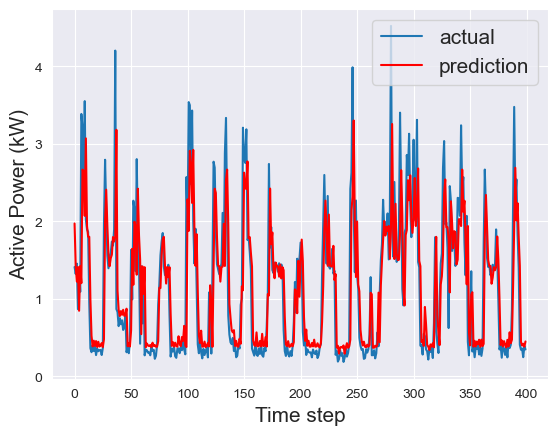

In [23]:
yhat = model.predict(X_test_int16)

aa = [x for x in range(400)]
plt.plot(aa, y_test[:400], label="actual")
plt.plot(aa, yhat[:400], 'r', label="prediction")
plt.ylabel('Active Power (kW)', size=15)
plt.xlabel('Time step', size=15)
plt.legend(fontsize=15)
plt.show()